# Introduction to K-Nearest Neighbors (KNN) Algorithm

Below is a combined notebook that introduces the K-Nearest Neighbors (KNN) algorithm, covering both theoretical concepts and practical implementation using the Iris dataset.


### CLASSIFICATION ALGORITHM:  K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is one of the simplest machine learning algorithms used for classification and regression. It's an instance-based learning algorithm that works by finding the K most similar instances in the training data and making a prediction based on their class (for classification) or value (for regression).

### How KNN Works:
1. Stores all available cases
2. Classifies new cases based on a similarity measure (distance function)
3. Uses majority voting (for classification) or averaging (for regression) among the K nearest neighbors

### Key Parameters:
- **K**: Number of neighbors to consider
- **Distance metric**: Typically Euclidean distance, but can be others like Euclidean, Mahanalobis or Manhattan distance
- **Weighting function**: Uniform (all neighbors weighted equally) or distance-based (closer neighbors have more influence)

### Advantages:
- Simple to understand and implement
- No assumptions about data distribution
- Can be used for both classification and regression

### Disadvantages:
- Computationally expensive for large datasets
- Sensitive to irrelevant features and the scale of the data
- Requires careful selection of K

## Load Data

We'll use the famous Iris dataset for our KNN demonstration. This dataset contains measurements of 150 iris flowers from three species:
- Iris setosa
- Iris virginica
- Iris versicolor

For each flower, we have four features:
1. Sepal length (cm)
2. Sepal width (cm)
3. Petal length (cm)
4. Petal width (cm)

In [ ]:
# import the dataset
# sklearns has a few in-built datasets
from sklearn.datasets import load_iris

In [ ]:
# get our dataset
iris_dataset = load_iris()
type(iris_dataset)


# returns a new type of object, called a bunch object -> very similar to a dictionary
#iris_dataset

In [ ]:
# these datasets actually have some nice metadata
#print(iris_dataset['DESCR'])
#print(iris_dataset['data'])
print(iris_dataset['feature_names'])

In [ ]:
# Convert to pandas DataFrame for a more readable format 
import pandas as pd
features = pd.DataFrame(iris_dataset['data'], columns = iris_dataset['feature_names'])
display(features.shape)
features.head()

In [ ]:
labels = pd.Series(iris_dataset['target'],name='label')
display(labels.shape)
labels.head()

final = pd.concat([features, labels], axis = 1)
final.tail()

## Analyze the data

In [ ]:
#we can see that all features are pretty reasonable predictors
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(final, hue = 'label')

## Build a model to classify new flowers

### Hide imagine

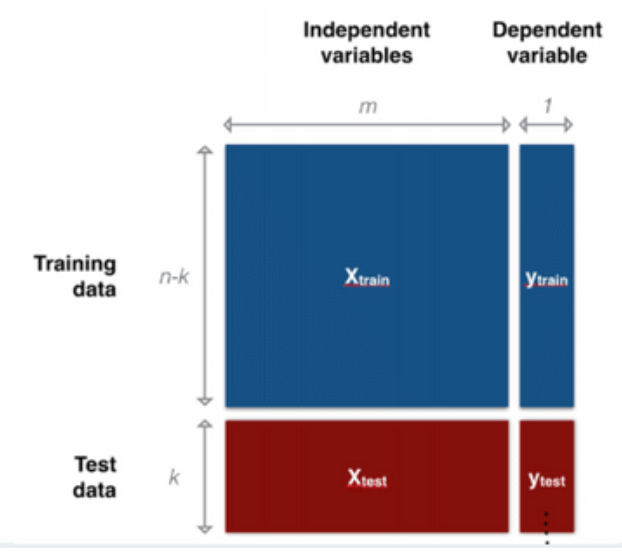

### Prepare the data

In [ ]:
# Let's get to the machine learnign part!!
# split our data into training and test datasets

#final.info()

######## BUILD TRAIN DATA #########
# X_train: 4 features and only 80% of the data points
X_train = final.iloc[0:120, 0:4]

# y_train: label and the same 80% of the data:
y_train = final.iloc[0:120, 4]
####################################

######## BUILD TEST DATA ########
# X_test: 4 features and THE OTHER 20% of the data points
X_test = final.iloc[120:150, 0:4]

# y_test: label and the same 20% of the data:
y_test = final.iloc[120:150, 4]
####################################

#X_train.info()
#y_train.describe()
#X_test.info()
#y_test.describe()

In [ ]:
## Logically, there is a python package for this...
from sklearn.model_selection import train_test_split

# sklearn accepts both numpy arrays and pandas dataframes
X_train, X_test, y_train, y_test = train_test_split(features, labels, random_state = 0, test_size = 0.20) 
#X_train, X_test, y_train, y_test = train_test_split(iris_dataset['data'], iris_dataset['target'],random_state = 0, test_size = 0.25) 

#random_state for reproducibility
#test_size = 0.25 by default but you can set it

#X_train.info()
y_train.describe()
#X_test.info()
#y_test.describe()

## Just this once, lets build the model by hand

### Lets discuss this in a 2D world:

In [ ]:
import seaborn as sns
#sns.scatterplot(data=final, x='sepal length (cm)', y='sepal width (cm)' , hue = 'label')

# A wild new_point as appeared
new_point = pd.DataFrame([[6, 4, 3]], columns=['sepal length (cm)', 'sepal width (cm)', 'label'])
sns.scatterplot(data=pd.concat([final, new_point]), x='sepal length (cm)', y='sepal width (cm)' , hue = 'label')

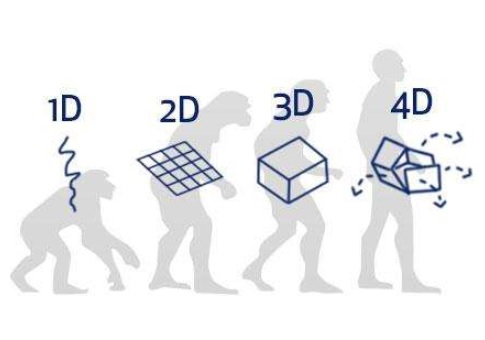

### Compute Distance in 2D

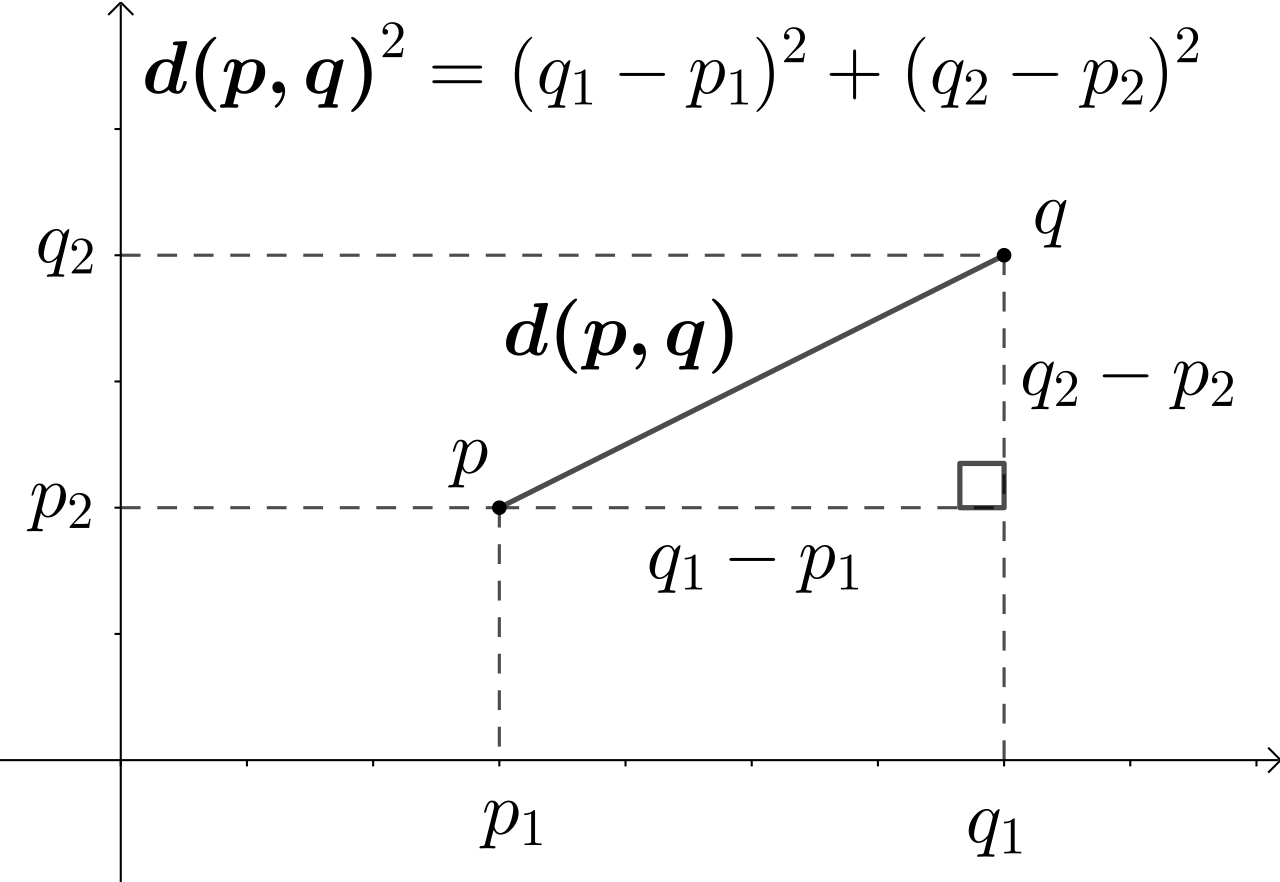

### Compute the Distance and get the label....... in 4D

In [ ]:
### Steps we need to take to build our model:
# #1: Build a function that computes the distance of the new entry point and all the data points
# #2: Check the labels the k-nearest-neighbours of the new data point 
# #3: Assign the label of the majority of the surronding data points to the new datapoint

import numpy as np
from scipy import stats

final.describe()

new_point = pd.DataFrame([[6, 4, 5, 0.5, 8]], \
                         columns=['sepal length (cm)', \
                                  'sepal width (cm)', \
                                  'petal length (cm)', \
                                  'petal width (cm)', \
                                  'label'])
print(type(new_point))
print(new_point)

In [ ]:
######## STEP 0 ###############
# Compute distance for one point
dist_sqr = (X_train.iloc[0, 0] - new_point.iloc[0,0])**2 \
         + (X_train.iloc[0, 1] - new_point.iloc[0,1])**2 \
         + (X_train.iloc[0, 2] - new_point.iloc[0,2])**2 \
         + (X_train.iloc[0, 3] - new_point.iloc[0,3])**2
dist = np.sqrt(dist_sqr)
print(dist)

# Of course there is a easier way to do this...
dist = np.linalg.norm(X_train.iloc[0, 0:4]-new_point.iloc[0, 0:4])
print(dist)

In [ ]:
######## STEP 1 ###############
# Compute distances for all the points:

euc_distances = pd.DataFrame(columns = ['dist'])
for i in range(0, len(X_train.index)):
  #print(i)
  X_train.iloc[i, 0:4]
  dist = np.linalg.norm(X_train.iloc[i, 0:4]-new_point.iloc[0, 0:4])
  euc_distances.loc[i] = dist
  
euc_distances.head()

In [ ]:
######## STEP 2 ###############
k_nearest_neighbours = euc_distances.nsmallest(5, 'dist')
print(k_nearest_neighbours.index)

In [ ]:
######## STEP 3 ###############
## Get the 5 labels:
label_1 = y_train.iloc[k_nearest_neighbours.index[0]]
label_2 = y_train.iloc[k_nearest_neighbours.index[1]]
label_3 = y_train.iloc[k_nearest_neighbours.index[2]]
label_4 = y_train.iloc[k_nearest_neighbours.index[3]]
label_5 = y_train.iloc[k_nearest_neighbours.index[4]]

labels = np.array([label_1, label_2, label_3, label_4, label_5])
new_point_label = int(stats.mode(labels)[0])
print(f'The label of the new point is {new_point_label}')

## KNN using Scikit Learn: of course Python has a way to do this...

#### Build out model and make a prediction for "new_point"

In [ ]:
# Create an instance of the model
# we've seen this already but it bears repeating: sklearn and ML packages in general require you to create an empty model before you use it
# think of it as creating an empty list before an .append() loop or something similar
from sklearn.neighbors import KNeighborsClassifier

# define hyperparameters here
knn = KNeighborsClassifier(n_neighbors = 5)

In [ ]:
# trainin in sklearn and other python ML packages is called "fit" 
# we naturally need to train in our data
knn.fit(X_train, y_train)

# your model is ready to make predictions!!! 

In [ ]:
# Lets see the model in action
knn.predict([new_point.iloc[0, 0:4]])

#### But how good is our model?

In [ ]:
# evaluate our fit model compared to our test dataset
y_predict = knn.predict(X_test)
y_predict

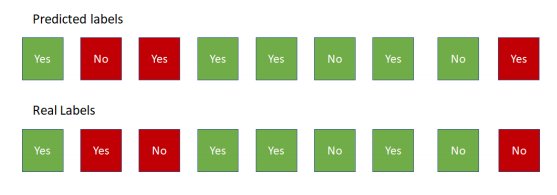

In [ ]:
# What is this score?
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

### EXTRA: Choosing the Right K Value

One critical aspect of KNN is selecting the appropriate value for K. Let's explore how different K values affect performance.

In [ ]:
# Try K values from 1 to 20
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid()
plt.show()